## Notebook 1. Dataset Exploration
### eICU External Validation  → MIMIC-III

---

**Project Goal:** Predict ICU mortality using clinical features from the eICU   dataset, with external validation on the MIMIC-III.

**Clinical Motivation:**  
Early and accurate mortality prediction in the ICU enables clinicians to:
- Prioritise high-risk patients for closer monitoring and intervention
- Allocate scarce ICU resources more efficiently
- Benchmark ICU performance against risk-adjusted expected mortality

# 1. Environmental Setup

In [87]:
# Install any missing libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn
!pip install -q xgboost lightgbm shap missingno pyarrow openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

SEED = 42
np.random.seed(SEED)

print('Environment ready')

Environment ready


In [88]:
from google.colab import drive
drive.mount('/content/drive')

EICU_PATH = '/content/drive/MyDrive/AI in Medicine/data/output_data/eicu_train/eicu_features.csv'
# This uses a system command to count the lines in the actual file
!wc -l "{EICU_PATH}"
MIMIC_PATH  = '/content/drive/MyDrive/AI in Medicine/data/output_data/mimic_val/mimic_features.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2521 /content/drive/MyDrive/AI in Medicine/data/output_data/eicu_train/eicu_features.csv


In [89]:
import os

# This lists everything in your "AI in Medicine" folder
folder_path = '/content/drive/MyDrive/AI in Medicine/data/output_data/eicu_train/'

if os.path.exists(folder_path):
    print("Folder found! Files inside:")
    print(os.listdir(folder_path))
else:
    print("Folder NOT found. Check your Drive path again.")

Folder found! Files inside:
['eicu_features.csv']


# 2. EICU (Training Dataset)

In [90]:
import pandas as pd

import pandas as pd

# 1. Load the raw file
df_eicu = pd.read_csv(EICU_PATH, header=None)

# 2. Extract the first row as the names
names_eicu = df_eicu.iloc[0].values

# 3. Create the dictionary {Index: Name}
feature_map_eicu = {i: name for i, name in enumerate(names_eicu)}

# 4. Print the entire list clearly
print("--- EICU FEATURE MAP ---")
for idx, name in feature_map_eicu.items():
    print(f"Index [{idx}] : {name}")

print("Data successfully indexed!")
print(f"Dataset now has {df_eicu.shape[1]} columns named 0 to 72.")
print(df_eicu.shape)


--- EICU FEATURE MAP ---
Index [0] : stay_id
Index [1] : age_clean
Index [2] : gender_binary
Index [3] : ethnicity_grp
Index [4] : icu_los_days
Index [5] : careunit
Index [6] : admit_source
Index [7] : mortality
Index [8] : albumin_max
Index [9] : alt_max
Index [10] : bicarbonate_max
Index [11] : bun_max
Index [12] : creatinine_max
Index [13] : glucose_max
Index [14] : hematocrit_max
Index [15] : hemoglobin_max
Index [16] : inr_max
Index [17] : lactate_max
Index [18] : platelets_max
Index [19] : potassium_max
Index [20] : sodium_max
Index [21] : wbc_max
Index [22] : albumin_mean
Index [23] : alt_mean
Index [24] : bicarbonate_mean
Index [25] : bun_mean
Index [26] : creatinine_mean
Index [27] : glucose_mean
Index [28] : hematocrit_mean
Index [29] : hemoglobin_mean
Index [30] : inr_mean
Index [31] : lactate_mean
Index [32] : platelets_mean
Index [33] : potassium_mean
Index [34] : sodium_mean
Index [35] : wbc_mean
Index [36] : albumin_min
Index [37] : alt_min
Index [38] : bicarbonate_min
I

In [91]:
df_eicu = df_eicu.drop(df_eicu.index[0])

print(df_eicu.head())
print( feature_map_eicu)

       0     1    2      3                   4     5               6  7    8   \
1  141764  87.0  0.0  White  0.2388888888888889  MICU         Unknown  0  NaN   
2  141765  87.0  0.0  White              1.5625  MICU         Unknown  0  NaN   
3  143870  76.0  1.0  White  0.5506944444444445  SICU  Operating Room  0  NaN   
4  144815  34.0  0.0  White  0.7784722222222222  MICU       Emergency  0  3.6   
5  145427  61.0  1.0  White  0.9506944444444444  SICU       Emergency  0  NaN   

     9     10    11    12     13    14    15   16   17     18   19     20  \
1   NaN   NaN   NaN   NaN    NaN   NaN   NaN  NaN  NaN    NaN  NaN    NaN   
2   NaN  21.0  28.0  1.04   61.0  37.8  12.3  NaN  NaN  191.0  4.1  139.0   
3   NaN  25.0  14.0  1.14  140.0  34.1  12.3  NaN  NaN  152.0  4.4  139.0   
4  42.0  26.0   6.0  0.63   82.0  36.6  12.3  1.0  NaN  319.0  3.7  141.0   
5   NaN  27.0  14.0  1.05  139.0  40.4  13.3  NaN  NaN  196.0  4.5  141.0   

     21   22    23    24    25     26     27    28

# 2. MIMIC (Testing Dataset)

In [92]:
import pandas as pd

import pandas as pd

# 1. Load the raw file
df_mimic = pd.read_csv(MIMIC_PATH, header=None)

# 2. Extract the first row as the names
names_mimic = df_mimic.iloc[0].values

# 3. Create the dictionary {Index: Name}
feature_map_mimic = {i: name for i, name in enumerate(names_mimic)}

# 4. Print the entire list clearly
print("--- MIMIC FEATURE MAP ---")
for idx, name in feature_map_mimic.items():
    print(f"Index [{idx}] : {name}")

print("Data successfully indexed!")
print(f"Dataset now has {df_mimic.shape[1]} columns named 0 to 73.")


--- MIMIC FEATURE MAP ---
Index [0] : stay_id
Index [1] : hadm_id
Index [2] : age_clean
Index [3] : gender_binary
Index [4] : ethnicity_grp
Index [5] : icu_los_days
Index [6] : careunit
Index [7] : admit_source
Index [8] : mortality
Index [9] : albumin_max
Index [10] : alt_max
Index [11] : bicarbonate_max
Index [12] : bun_max
Index [13] : creatinine_max
Index [14] : glucose_max
Index [15] : hematocrit_max
Index [16] : hemoglobin_max
Index [17] : inr_max
Index [18] : lactate_max
Index [19] : platelets_max
Index [20] : potassium_max
Index [21] : sodium_max
Index [22] : wbc_max
Index [23] : albumin_mean
Index [24] : alt_mean
Index [25] : bicarbonate_mean
Index [26] : bun_mean
Index [27] : creatinine_mean
Index [28] : glucose_mean
Index [29] : hematocrit_mean
Index [30] : hemoglobin_mean
Index [31] : inr_mean
Index [32] : lactate_mean
Index [33] : platelets_mean
Index [34] : potassium_mean
Index [35] : sodium_mean
Index [36] : wbc_mean
Index [37] : albumin_min
Index [38] : alt_min
Index [3

In [93]:
df_mimic = df_mimic.drop(df_mimic.index[0])

print(df_mimic.head())
print(feature_map_mimic)
print(df_mimic.shape)

       0       1     2  3        4        5     6          7  8    9      10  \
1  206504  142345  70.0  0  African   1.6325  MICU  Emergency  0  2.7    NaN   
2  232110  105331  36.0  0  Unknown  13.8507  MICU   Transfer  1  2.6  254.0   
3  264446  165520  87.0  0  Unknown   2.6499  MICU   Transfer  1  NaN   29.0   
4  204881  199207  73.0  0    White   2.1436   CCU  Emergency  0  2.8    NaN   
5  228977  177759  48.0  1    White   1.2938  MICU   Transfer  1  NaN  155.0   

     11    12   13     14    15   16   17    18     19   20     21    22   23  \
1  31.0  11.0  3.5   84.0  36.9  NaN  3.5   1.3  106.0  4.4  139.0   4.6  2.7   
2  23.0   3.0  0.7   79.0  34.0  NaN  9.5   NaN  299.0  5.9  136.0  10.6  2.6   
3  29.0  32.0  1.7  165.0  29.2  NaN  1.5   NaN  220.0  4.2  138.0  16.2  NaN   
4  29.0   3.0  0.3  137.0  27.5  NaN  1.2   NaN  202.0  3.0  139.0  15.8  2.8   
5  18.0  48.0  6.4  360.0  36.0  NaN  2.1  26.3   85.0  6.3  141.0   6.8  NaN   

      24    25     26           

In [103]:
# 1. Get the list of columns from eICU to use as a template
# (We assume eICU is the 'standard' with 73 columns)
eicu_cols = df_eicu.columns.tolist()

# 2. Identify the 'hadm_id' in MIMIC (which eICU doesn't have)
# Based on your previous output, it's in Column 1
mimic_hadm_id = df_mimic[1]

# 3. Create a new MIMIC dataframe using ONLY the columns that exist in eICU
# This aligns the first 73 columns perfectly
df_mimic_aligned = df_mimic.drop(columns=[1])
df_mimic_aligned.columns = eicu_cols

# 4. Add the hadm_id at the very end (Index 73)
df_mimic_aligned['hadm_id_extra'] = mimic_hadm_id
df_mimic = df_mimic_aligned

print(f"eICU Shape: {df_eicu.shape}")
print(f"MIMIC  Shape: {df_mimic.shape}")
print("Mortality is now at Index 7 for BOTH datasets!")
print(df_mimic.head(1))
print(df_eicu.head(1))


eICU Shape: (2520, 73)
MIMIC  Shape: (136, 74)
Mortality is now at Index 7 for BOTH datasets!
        0       1     2          3  4    5    6     7     8    9    10    11  \
1  206504  1.6325  MICU  Emergency  0  2.7  NaN  31.0  11.0  3.5  84.0  36.9   

    12   13   14     15   16     17   18   19   20    21    22   23    24  \
1  NaN  3.5  1.3  106.0  4.4  139.0  4.6  2.7  NaN  31.0  11.0  3.5  84.0   

     25   26   27   28     29   30     31   32   33   34    35    36   37  \
1  36.9  NaN  3.5  1.3  106.0  4.4  139.0  4.6  2.7  NaN  31.0  11.0  3.5   

     38    39   40   41   42     43   44     45   46    47     48  \
1  84.0  36.9  NaN  3.5  1.3  106.0  4.4  139.0  4.6  60.0  104.0   

                 49    50     51     52   53                  54       55  \
1  80.6667022705078  91.0  132.0  100.0  NaN  51.285714285714285  86.0625   

                 56      57                  58                 59   60    61  \
1  72.8095359802246  28.875  115.85714285714286  98.53333333

**1. Data Quality & Missingness (The "Cleaning" Check)**

Percentage of Missing Values per Feature (eICU):
61   93.968
60   93.968
59   93.968
65   84.206
66   84.206
      ...  
4     0.000
3     0.000
0     0.000
5     0.000
72    0.000
Length: 73, dtype: float64


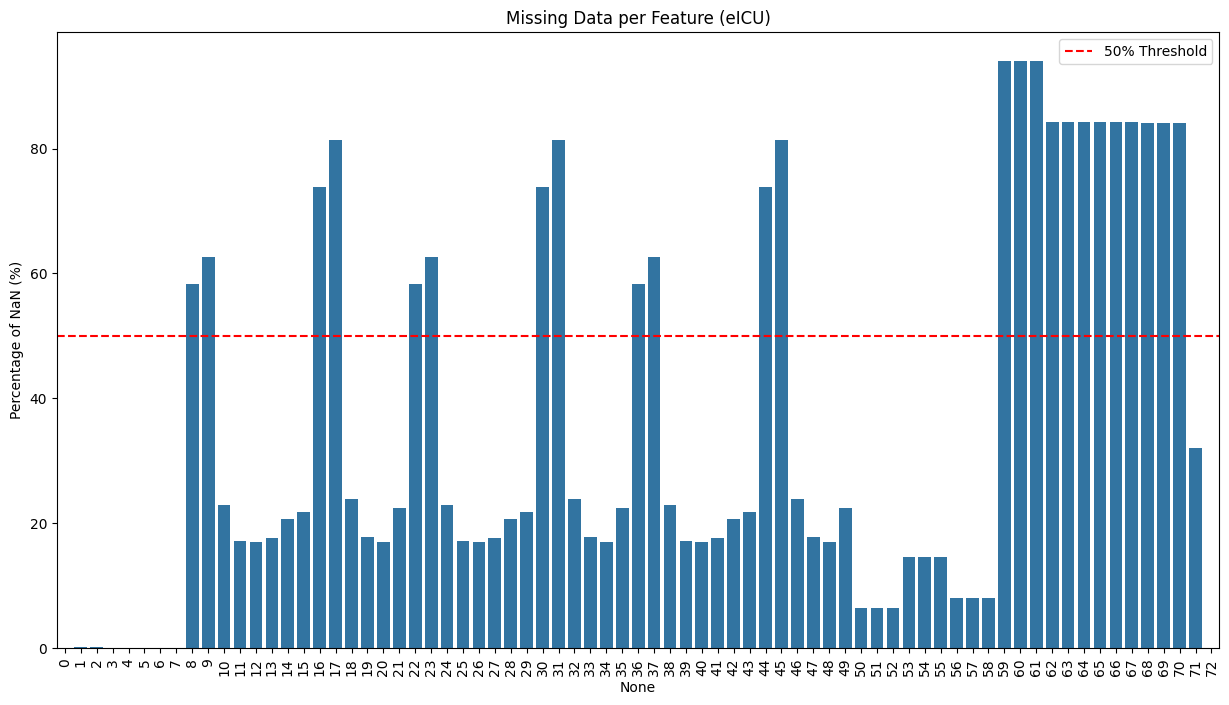

Percentage of Missing Values per Feature (MIMIC):
69              93.382
62              93.382
55              93.382
14              87.500
28              87.500
                 ...  
5                0.000
70               0.000
71               0.000
72               0.000
hadm_id_extra    0.000
Length: 74, dtype: float64


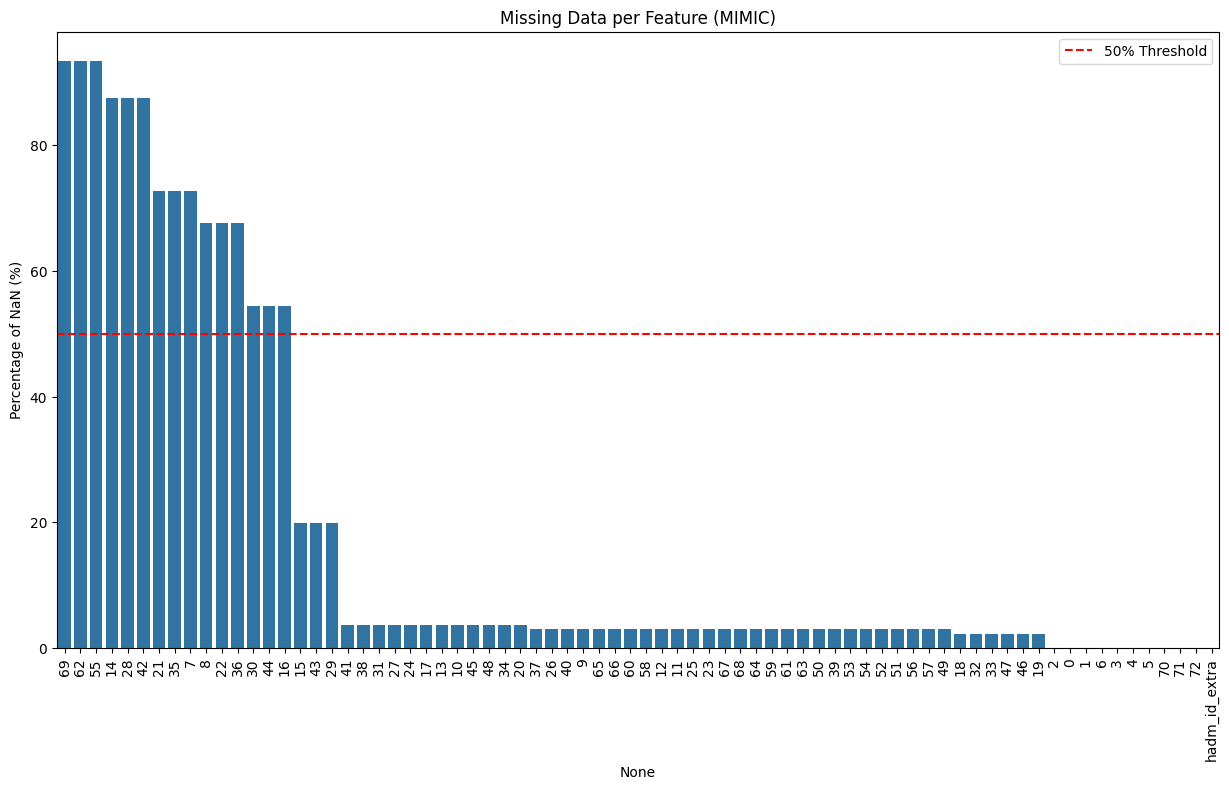

In [99]:
# Calculate the percentage of missing values for each column
missing_pct_eicu = df_eicu.isnull().mean() * 100

# Sort them from highest to lowest
missing_pct_eicu = missing_pct_eicu.sort_values(ascending=False)

print("Percentage of Missing Values per Feature (eICU):")
print(missing_pct_eicu)

plt.figure(figsize=(15, 8))
sns.barplot(x=missing_pct_eicu.index, y=missing_pct_eicu.values)
plt.xticks(rotation=90) # Rotate labels so they don't overlap
plt.ylabel('Percentage of NaN (%)')
plt.title('Missing Data per Feature (eICU)')
plt.axhline(y=50, color='r', linestyle='--', label='50% Threshold') # Reference line
plt.legend()
plt.show()



#MIMIC
# Calculate the percentage of missing values for each column
missing_pct_mimic = df_mimic.isnull().mean() * 100

# Sort them from highest to lowest
missing_pct_mimic = missing_pct_mimic.sort_values(ascending=False)

print("Percentage of Missing Values per Feature (MIMIC):")
print(missing_pct_mimic)

plt.figure(figsize=(15, 8))
sns.barplot(x=missing_pct_mimic.index, y=missing_pct_mimic.values)
plt.xticks(rotation=90) # Rotate labels so they don't overlap
plt.ylabel('Percentage of NaN (%)')
plt.title('Missing Data per Feature (MIMIC)')
plt.axhline(y=50, color='r', linestyle='--', label='50% Threshold') # Reference line
plt.legend()
plt.show()


**2. Target Analysis (The "Class Imbalance" Check)**

In [101]:
# Function to analyze mortality
def analyze_mortality(df, name, target_idx=7):
    # Ensure column is numeric
    target = pd.to_numeric(df[target_idx], errors='coerce').dropna()

    counts = target.value_counts()
    percentage = target.value_counts(normalize=True) * 100

    print(f"--- {name} Mortality Analysis ---")
    print(f"Total Patients: {len(target)}")
    print(f"Survived (0): {counts[0]} ({percentage[0]:.2f}%)")
    print(f"Died (1):     {counts[1]} ({percentage[1]:.2f}%)")
    print("-" * 30)
    return percentage[1]

# Analyze both
eicu_rate = analyze_mortality(df_eicu, "eICU")
mimic_rate = analyze_mortality(df_mimic, "MIMIC")


--- eICU Mortality Analysis ---
Total Patients: 2520
Survived (0): 2394 (95.00%)
Died (1):     126 (5.00%)
------------------------------
--- MIMIC Mortality Analysis ---
Total Patients: 37


KeyError: 0

A highly imbalanced dataset so that *Accuracy* is a forbidden metric for this project. Instead: AUPRC or Sensitivity (Recall)

**3. Feature Distribution & Outliers (The "Sanity" Check)**

**4. Bivariate Analysis (The "Predictor" Check)**

**5. Dataset Shift (The "Validation" Check)**

In [ ]:
# Compare Creatinine levels between survivors and non-survivors
# Using index 12 (creatinine_max) and index 7 (mortality)
plt.figure(figsize=(8, 6))
sns.boxplot(x=7, y=12, data=df_eicu.iloc[1:])
plt.title(f"Creatinine Max vs Mortality")
plt.xlabel("Mortality (0=Survive, 1=Died)")
plt.ylabel("Creatinine Max")
plt.show()

```
Column Range           Likely Feature Type                 

0 - 7                  Demographics/Admission
8 - 37                 Comorbidities (Binary)
38 - 59                Vital Signs (Min/Max/Mean)
60 - 86                Lab Results
87 - 91                Metrics
92 (Last)              The Target Label
```



```
Examples in your data
"Age (76), Gender (1=M), Weight (96.8), Admission Type, etc."
"Indicators for Diabetes, Hypertension, Renal Failure (0 or 1)."
"Heart Rate, Temp, BP, SpO2."
"Glucose, Creatinine, Hemoglobin, WBC, pH, Lactate."
"Mortality (1 = Deceased, 0 = Survived)."
```
